In [2]:
import os
import numpy as np
import torch
import torch.nn as nn
from torchvision import transforms, models
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from sklearn.model_selection import train_test_split
import glob
from pathlib import Path
from sklearn.metrics import confusion_matrix

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [4]:
from torch.utils.data import Dataset
from PIL import Image
import os

class BreaKHisDataset(Dataset):
    def __init__(self, file_paths, labels, transform=None):
        self.file_paths = file_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        image = Image.open(self.file_paths[idx]).convert('RGB')
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, label


In [5]:
import os
import glob
from pathlib import Path

def get_image_paths_and_labels(root_dir):
    file_paths = []
    labels = []
    
    class_mapping = {
        'SOB_B_A': 0,   
        'SOB_B_F': 1,   
        'SOB_B_PT': 2,   
        'SOB_B_TA': 3,   
        'SOB_M_DC': 4,   
        'SOB_M_LC': 5,   
        'SOB_M_MC': 6,   
        'SOB_M_PC': 7    
    }
    
    img_extensions = ('.png', '.jpg', '.jpeg')
    
    for class_dir in os.listdir(root_dir):
        class_path = os.path.join(root_dir, class_dir)
        
        if not os.path.isdir(class_path):
            continue
            
        if class_dir in class_mapping:
            label = class_mapping[class_dir]
        else:
            print(f"Skipping unknown directory: {class_dir}")
            continue
            
        for img_file in os.listdir(class_path):
            if img_file.lower().endswith(img_extensions):
                file_paths.append(os.path.join(class_path, img_file))
                labels.append(label)
    
    print(f"Found {len(file_paths)} images across {len(class_mapping)} classes.")
    print("Class distribution:", np.bincount(labels))
    return file_paths, labels, list(class_mapping.keys())

In [6]:
!ls /kaggle/input/split-data/BreakHis_splits/


test  train  val


In [7]:
IMG_SIZE = 227
MEAN = [0.485, 0.456, 0.406]
STD = [0.229, 0.224, 0.225]

In [8]:
train_transform = transforms.Compose([
    transforms.RandomRotation(30),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.RandomAffine(degrees=0, translate=(0.15, 0.15)),
    transforms.GaussianBlur(kernel_size=3),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
    transforms.RandomErasing(p=0.5, scale=(0.02, 0.1), ratio=(0.3, 3.3))
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])


In [9]:
from sklearn.model_selection import train_test_split
from torchvision import transforms
from torch.utils.data import DataLoader



train_dir = "/kaggle/input/final1/balanced_dataset"
train_paths, train_labels, class_names = get_image_paths_and_labels(train_dir)
train_dataset = BreaKHisDataset(train_paths, train_labels, train_transform)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)


val_dir = "/kaggle/input/split-data/BreakHis_splits/val/"
val_paths, val_labels, _ = get_image_paths_and_labels(val_dir)
val_dataset = BreaKHisDataset(val_paths, val_labels, test_transform)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)


test_dir = "/kaggle/input/split-data/BreakHis_splits/test/"
test_paths, test_labels, _ = get_image_paths_and_labels(test_dir)
test_dataset = BreaKHisDataset(test_paths, test_labels, test_transform)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)


Found 8000 images across 8 classes.
Class distribution: [1000 1000 1000 1000 1000 1000 1000 1000]
Found 400 images across 8 classes.
Class distribution: [50 50 50 50 50 50 50 50]
Found 800 images across 8 classes.
Class distribution: [100 100 100 100 100 100 100 100]


In [10]:
print("Unique test labels:", sorted(set(test_labels)))


Unique test labels: [0, 1, 2, 3, 4, 5, 6, 7]


In [11]:

class SwinBreastCancer(nn.Module):
    def __init__(self, num_classes=8): 
        super(SwinBreastCancer, self).__init__()
        self.swin = models.swin_b(weights=models.Swin_B_Weights.IMAGENET1K_V1)
        self.swin.head = nn.Linear(1024, num_classes) 

    def forward(self, x):
        return self.swin(x)


num_classes = 8 
model = SwinBreastCancer(num_classes=num_classes).to(device)


pretrained_weights = torch.load("/kaggle/input/swin_b/pytorch/default/1/swin_b_breast_cancer.pth", map_location=device)

pretrained_weights.pop('swin.head.weight', None)
pretrained_weights.pop('swin.head.bias', None)


model.swin.load_state_dict(pretrained_weights, strict=False)

model.train()

Downloading: "https://download.pytorch.org/models/swin_b-68c6b09e.pth" to /root/.cache/torch/hub/checkpoints/swin_b-68c6b09e.pth
100%|██████████| 335M/335M [00:14<00:00, 24.1MB/s] 
/tmp/ipykernel_31/1608322064.py:16: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded fi

SwinBreastCancer(
  (swin): SwinTransformer(
    (features): Sequential(
      (0): Sequential(
        (0): Conv2d(3, 128, kernel_size=(4, 4), stride=(4, 4))
        (1): Permute()
        (2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      )
      (1): Sequential(
        (0): SwinTransformerBlock(
          (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
          (attn): ShiftedWindowAttention(
            (qkv): Linear(in_features=128, out_features=384, bias=True)
            (proj): Linear(in_features=128, out_features=128, bias=True)
          )
          (stochastic_depth): StochasticDepth(p=0.0, mode=row)
          (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
          (mlp): MLP(
            (0): Linear(in_features=128, out_features=512, bias=True)
            (1): GELU(approximate='none')
            (2): Dropout(p=0.0, inplace=False)
            (3): Linear(in_features=512, out_features=128, bias=True)
            (4): Dropout(p

In [14]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=5e-5,              
    weight_decay=0.01,      
    eps=1e-8              
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='max',            
    factor=0.5,            
    patience=5,            
    verbose=True           
)

In [15]:
def train_model(model, epochs=60, patience=10):
   
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=5e-5,              
        weight_decay=0.01       
    )
    
   
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='max',            
        factor=0.5,            
        patience=5,            
        verbose=True           
    )
    
    best_val_acc = 0.0
    best_model_weights = None
    best_epoch = 0
    early_stop_counter = 0
    
    warmup_epochs = 5
    initial_lr = 5e-5

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        
        if epoch < warmup_epochs:
            lr = initial_lr * (epoch + 1) / warmup_epochs
            for param_group in optimizer.param_groups:
                param_group['lr'] = lr

        for batch_idx, (images, labels) in enumerate(train_loader):
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            if batch_idx % 10 == 0:
                current_lr = optimizer.param_groups[0]['lr']
                print(f'Epoch [{epoch+1}/{epochs}], Batch [{batch_idx}/{len(train_loader)}], Loss: {loss.item():.4f}, LR: {current_lr:.2e}')

        train_acc = 100 * correct / total
        val_loss, val_acc = evaluate(model, test_loader)
      
        scheduler.step(val_acc)
       
        current_lr = optimizer.param_groups[0]['lr']
        print(f'Epoch [{epoch+1}/{epochs}] Summary:')
        print(f'LR: {current_lr:.2e} | Train Loss: {running_loss/len(train_loader):.4f} | Train Acc: {train_acc:.2f}%')
        print(f'Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%\n')
      
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_weights = model.state_dict().copy()
            best_epoch = epoch
            early_stop_counter = 0
           
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'scheduler_state_dict': scheduler.state_dict(),
                'best_val_acc': best_val_acc,
            }, 'best_swin_model.pth')
            print(f'New best model saved with val accuracy: {best_val_acc:.2f}%\n')
        else:
            early_stop_counter += 1
            print(f'No improvement for {early_stop_counter}/{patience} epochs\n')
            
            if early_stop_counter >= patience:
                print(f'Early stopping triggered at epoch {epoch+1}!')
                print(f'Best validation accuracy: {best_val_acc:.2f}% (epoch {best_epoch+1})')
                break

   
    checkpoint = torch.load('best_swin_model.pth')
    model.load_state_dict(checkpoint['model_state_dict'])
    
    return model

In [16]:
def evaluate(model, loader):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return running_loss / len(loader), 100 * correct / total

In [17]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import confusion_matrix
import numpy as np

def print_metrics(model, loader, num_classes=8):
    label_names = [
        'Adenosis', 'Fibroadenoma', 'Phyllodes Tumor', 'Tubular Adenoma',
        'Ductal Carcinoma', 'Lobular Carcinoma', 'Mucinous Carcinoma', 'Papillary Carcinoma'
    ]


    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    cm = confusion_matrix(all_labels, all_preds, labels=list(range(num_classes)))
   
    accuracy = np.trace(cm) / np.sum(cm)
    print('Confusion Matrix:\n', cm)
    print(f'\nOverall Accuracy: {accuracy:.4f}\n')

    class_accuracies = []
    for i in range(num_classes):
        class_tp = cm[i, i]
        class_total = cm[i].sum()
        class_acc = class_tp / class_total if class_total > 0 else 0
        class_accuracies.append(class_acc)
        print(f'{label_names[i]:<20} Accuracy: {class_acc:.4f}')

    avg_class_accuracy = np.mean(class_accuracies)
    print(f'\nAverage Class Accuracy: {avg_class_accuracy:.4f}')


In [15]:
train_model(model, epochs=60)


Epoch [1/60], Batch [0/250], Loss: 2.1855, LR: 1.00e-05
Epoch [1/60], Batch [10/250], Loss: 2.1453, LR: 1.00e-05
Epoch [1/60], Batch [20/250], Loss: 2.0354, LR: 1.00e-05
Epoch [1/60], Batch [30/250], Loss: 2.0653, LR: 1.00e-05
Epoch [1/60], Batch [40/250], Loss: 2.0501, LR: 1.00e-05
Epoch [1/60], Batch [50/250], Loss: 1.9657, LR: 1.00e-05
Epoch [1/60], Batch [60/250], Loss: 2.0273, LR: 1.00e-05
Epoch [1/60], Batch [70/250], Loss: 1.9281, LR: 1.00e-05
Epoch [1/60], Batch [80/250], Loss: 1.8947, LR: 1.00e-05
Epoch [1/60], Batch [90/250], Loss: 1.9552, LR: 1.00e-05
Epoch [1/60], Batch [100/250], Loss: 1.9766, LR: 1.00e-05
Epoch [1/60], Batch [110/250], Loss: 1.8475, LR: 1.00e-05
Epoch [1/60], Batch [120/250], Loss: 1.9017, LR: 1.00e-05
Epoch [1/60], Batch [130/250], Loss: 1.7706, LR: 1.00e-05
Epoch [1/60], Batch [140/250], Loss: 1.8240, LR: 1.00e-05
Epoch [1/60], Batch [150/250], Loss: 1.8013, LR: 1.00e-05
Epoch [1/60], Batch [160/250], Loss: 1.8940, LR: 1.00e-05
Epoch [1/60], Batch [170/

/tmp/ipykernel_19/1110056317.py:100: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load('best_swin_model.pth')


Confusion Matrix:
 [[100   0   0   0   0   0   0   0]
 [  0  99   1   0   0   0   0   0]
 [  0   1  99   0   0   0   0   0]
 [  0   0   0 100   0   0   0   0]
 [  0   0   0   0  96   3   1   0]
 [  0   0   0   0   2  97   1   0]
 [  0   0   0   0   2   3  95   0]
 [  0   0   0   0   0   0   0 100]]

Overall Accuracy: 0.9825

Adenosis             Accuracy: 1.0000
Fibroadenoma         Accuracy: 0.9900
Phyllodes Tumor      Accuracy: 0.9900
Tubular Adenoma      Accuracy: 1.0000
Ductal Carcinoma     Accuracy: 0.9600
Lobular Carcinoma    Accuracy: 0.9700
Mucinous Carcinoma   Accuracy: 0.9500
Papillary Carcinoma  Accuracy: 1.0000

Average Class Accuracy: 0.9825


In [16]:
!ls /kaggle/input/swin98/pytorch/default/1/best_swin_model.pth

best_swin_model.pth


In [18]:

model = SwinBreastCancer(num_classes=8).to(device)
checkpoint = torch.load('/kaggle/input/swin98/pytorch/default/1/best_swin_model.pth', map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()


/tmp/ipykernel_31/2014312463.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load('/kaggle/input/swin98/pytorch/default/1/best_swin_model.pth', map_lo

SwinBreastCancer(
  (swin): SwinTransformer(
    (features): Sequential(
      (0): Sequential(
        (0): Conv2d(3, 128, kernel_size=(4, 4), stride=(4, 4))
        (1): Permute()
        (2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      )
      (1): Sequential(
        (0): SwinTransformerBlock(
          (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
          (attn): ShiftedWindowAttention(
            (qkv): Linear(in_features=128, out_features=384, bias=True)
            (proj): Linear(in_features=128, out_features=128, bias=True)
          )
          (stochastic_depth): StochasticDepth(p=0.0, mode=row)
          (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
          (mlp): MLP(
            (0): Linear(in_features=128, out_features=512, bias=True)
            (1): GELU(approximate='none')
            (2): Dropout(p=0.0, inplace=False)
            (3): Linear(in_features=512, out_features=128, bias=True)
            (4): Dropout(p

In [19]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import numpy as np
import torch

class_names = ['adenosis', 'fibroadenoma', 'phyllodes_tumor', 'tubular_adenoma',
               'ductal_carcinoma', 'lobular_carcinoma', 'mucinous_carcinoma', 'papillary_carcinoma']

benign_indices = set(range(4))
malignant_indices = set(range(4, 8))

all_preds, all_labels = [], []

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

print("📋 Classification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names, digits=4))

overall_acc = accuracy_score(all_labels, all_preds)
print(f"\nOverall Accuracy: {overall_acc:.4f}")

print("\nClass-wise Accuracy:")
for idx, name in enumerate(class_names):
    correct = ((all_preds == idx) & (all_labels == idx)).sum()
    total = (all_labels == idx).sum()
    acc = correct / total
    print(f"{name:22s}: {correct:3d}/{total:3d} = {acc:.4%}")

benign_mask = np.isin(all_labels, list(benign_indices))
malignant_mask = np.isin(all_labels, list(malignant_indices))

benign_acc = (all_preds[benign_mask] == all_labels[benign_mask]).sum() / benign_mask.sum()
malignant_acc = (all_preds[malignant_mask] == all_labels[malignant_mask]).sum() / malignant_mask.sum()

print(f"\nBenign Accuracy:    {benign_acc:.4f}")
print(f"Malignant Accuracy: {malignant_acc:.4f}")

cm = confusion_matrix(all_labels, all_preds)
print("\nConfusion Matrix:")
print(cm)



📋 Classification Report:
                     precision    recall  f1-score   support

           adenosis     1.0000    1.0000    1.0000       100
       fibroadenoma     0.9900    0.9900    0.9900       100
    phyllodes_tumor     0.9900    0.9900    0.9900       100
    tubular_adenoma     1.0000    1.0000    1.0000       100
   ductal_carcinoma     0.9600    0.9600    0.9600       100
  lobular_carcinoma     0.9417    0.9700    0.9557       100
 mucinous_carcinoma     0.9794    0.9500    0.9645       100
papillary_carcinoma     1.0000    1.0000    1.0000       100

           accuracy                         0.9825       800
          macro avg     0.9826    0.9825    0.9825       800
       weighted avg     0.9826    0.9825    0.9825       800


Overall Accuracy: 0.9825

Class-wise Accuracy:
adenosis              : 100/100 = 100.0000%
fibroadenoma          :  99/100 = 99.0000%
phyllodes_tumor       :  99/100 = 99.0000%
tubular_adenoma       : 100/100 = 100.0000%
ductal_carcinoma  


Confusion Matrix:
[[100   0   0   0   0   0   0   0]
 [  0  99   1   0   0   0   0   0]
 [  0   1  99   0   0   0   0   0]
 [  0   0   0 100   0   0   0   0]
 [  0   0   0   0  96   3   1   0]
 [  0   0   0   0   2  97   1   0]
 [  0   0   0   0   2   3  95   0]
 [  0   0   0   0   0   0   0 100]]


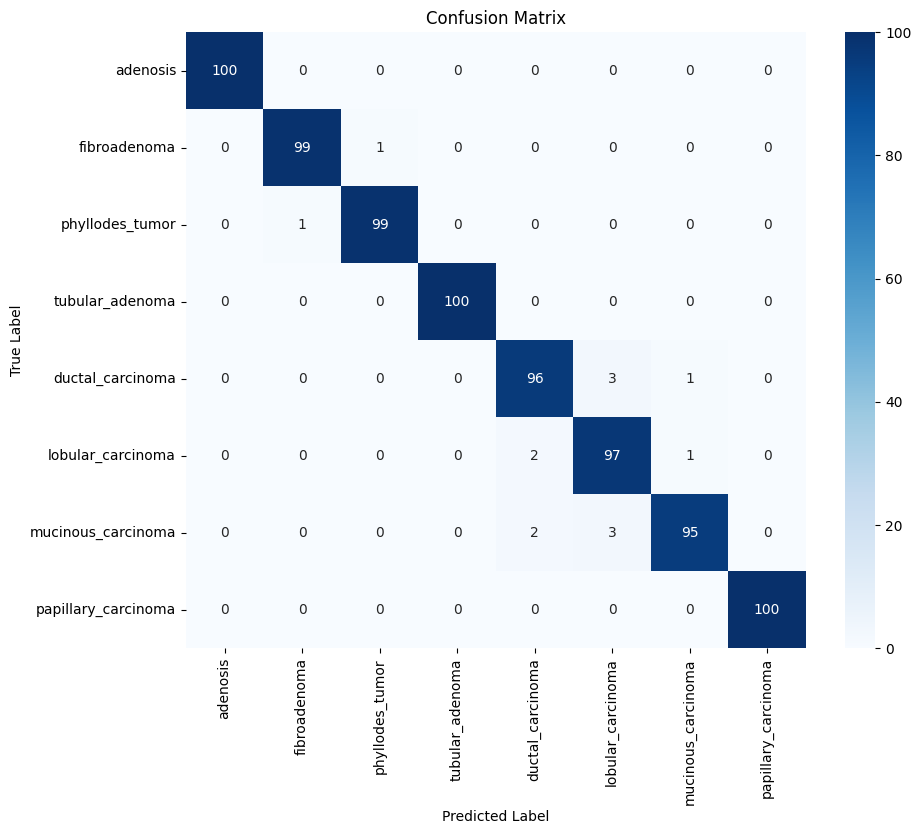

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(all_labels, all_preds)
print("\nConfusion Matrix:")
print(cm)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.show()
